In [14]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
diabetes = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
corr = diabetes.select_dtypes(['Float64','int64']).corr()

<Axes: >

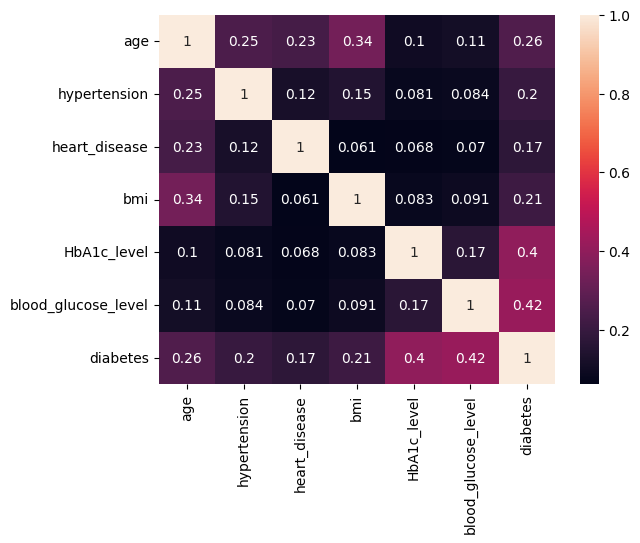

In [5]:
sns.heatmap(corr, annot=True)

In [6]:
diabetes['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [7]:
x = diabetes.drop(['blood_glucose_level','diabetes','smoking_history'], axis=1)
x['gender'] = x['gender'].map({'Male':1,'Female':0, 'Other':-1})
x

,gender,age,hypertension,heart_disease,bmi,HbA1c_level
0,0,80.0,0,1,25.19,6.6
1,0,54.0,0,0,27.32,6.6
2,1,28.0,0,0,27.32,5.7
3,0,36.0,0,0,23.45,5.0
4,1,76.0,1,1,20.14,4.8
...,...,...,...,...,...,...
99995,0,80.0,0,0,27.32,6.2
99996,0,2.0,0,0,17.37,6.5
99997,1,66.0,0,0,27.83,5.7
99998,0,24.0,0,0,35.42,4.0


In [8]:
y = diabetes['blood_glucose_level']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [10]:
LR_model = LinearRegression()


In [11]:
LR_model.fit(x_train,y_train)

LinearRegression()

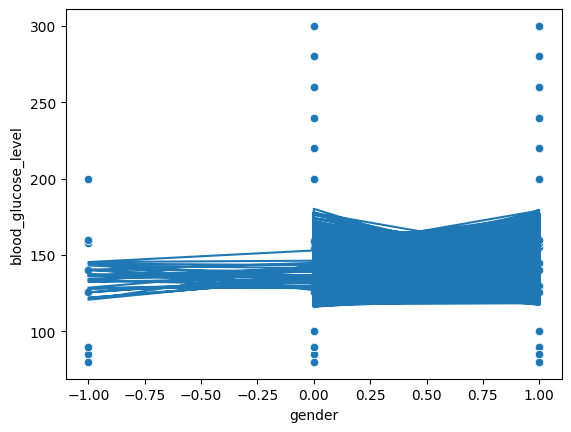

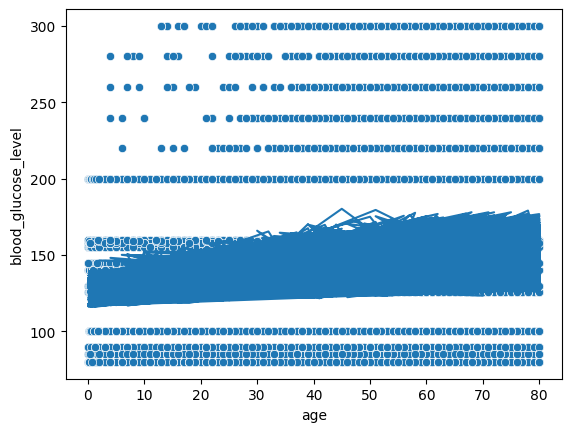

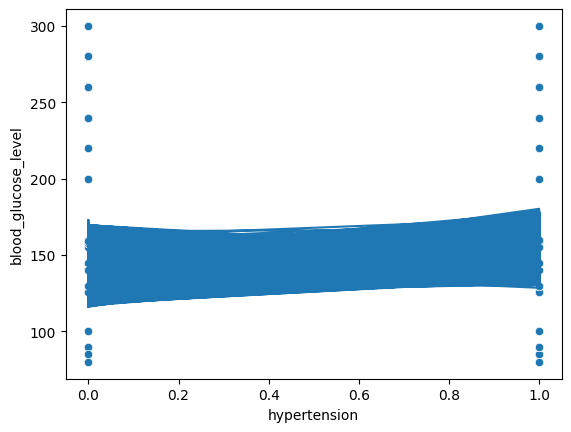

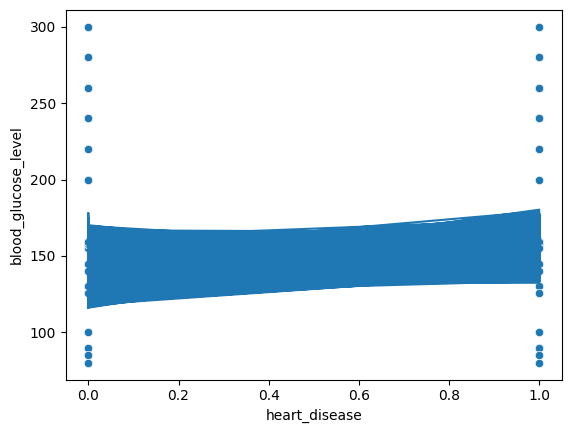

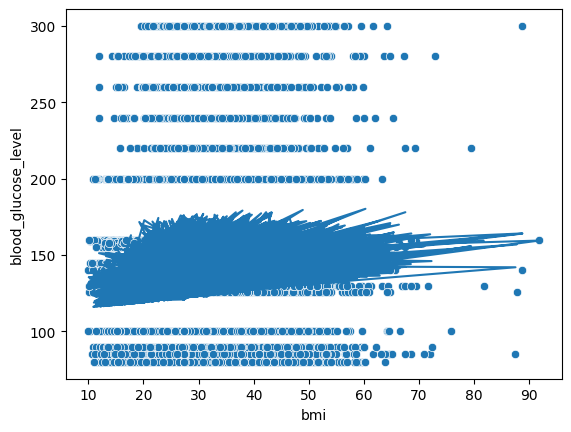

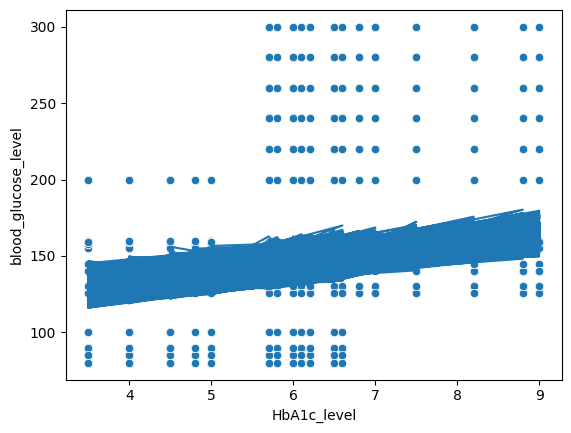

In [49]:
train_pred = LR_model.predict(x_train)
test_pred = LR_model.predict(x_test)
for col in x.columns:
    sns.scatterplot(x = x_train[col], y = y_train)
    sns.scatterplot(x = x_train[col], y = y_train)
    plt.plot(x_train[col],train_pred)
    plt.show()

In [12]:
test_pred = LR_model.predict(x_test)

In [17]:
print(mean_absolute_error(y_test, test_pred))
print(y_test.min(),y_test.max())

30.72912296676802
80 300
